In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [3]:
data = pd.read_csv("Mall_Customers.csv")

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
print("Dataset Shape:", data.shape)

print("\nColumns:")
print(data.columns)

print("\nDataset Info")
print(data.info())

print("\nStatistical Summary")
print(data.describe())

Dataset Shape: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Statistical Summary
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823

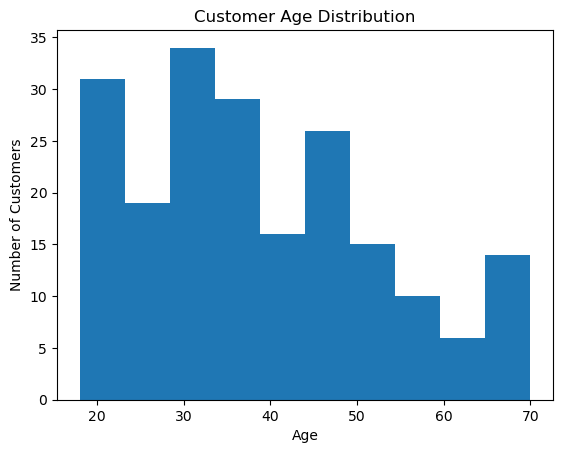

In [5]:
plt.hist(data['Age'], bins=10)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

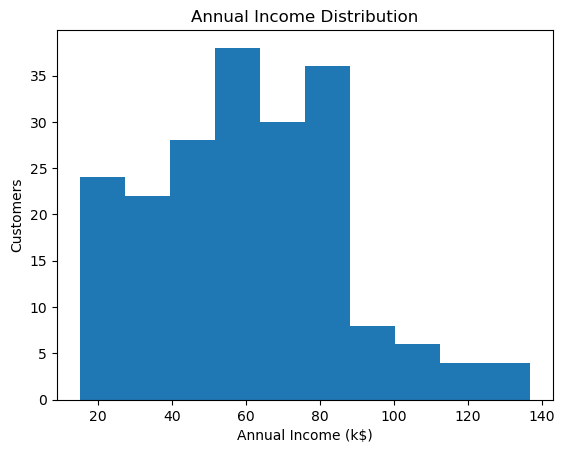

In [6]:
plt.hist(data['Annual Income (k$)'], bins=10)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Customers")

plt.show()

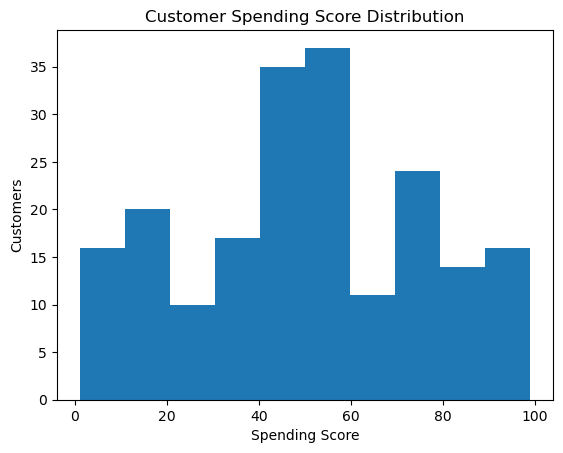

In [7]:
plt.hist(data['Spending Score (1-100)'], bins=10)

plt.title("Customer Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Customers")

plt.show()

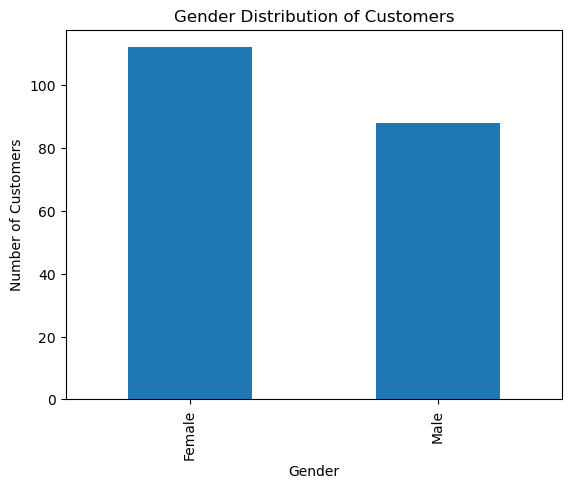

In [8]:
data['Gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

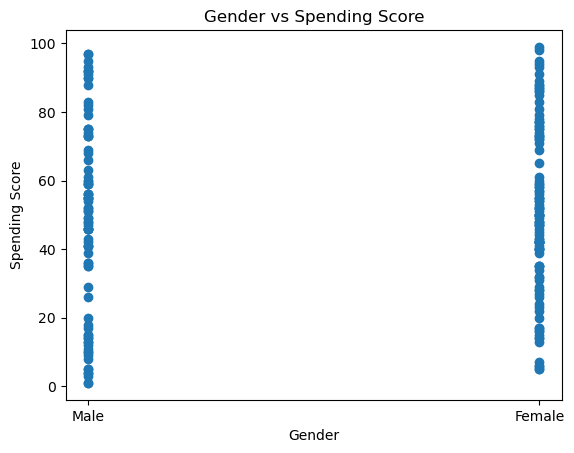

In [9]:
plt.scatter(data['Gender'], data['Spending Score (1-100)'])

plt.title("Gender vs Spending Score")
plt.xlabel("Gender")
plt.ylabel("Spending Score")

plt.show()

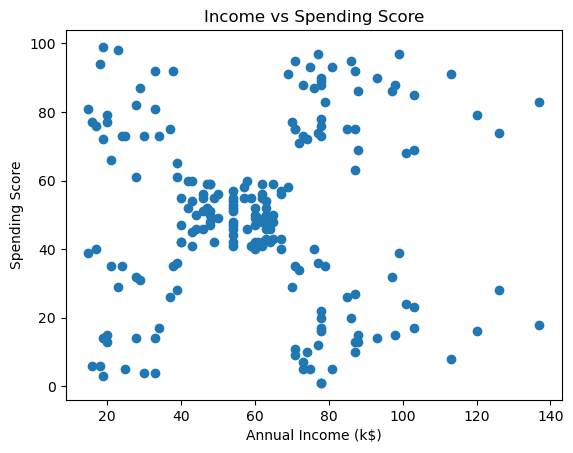

In [10]:
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [11]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

In [12]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X)
    wcss.append(model.inertia_)

C:\Users\jathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

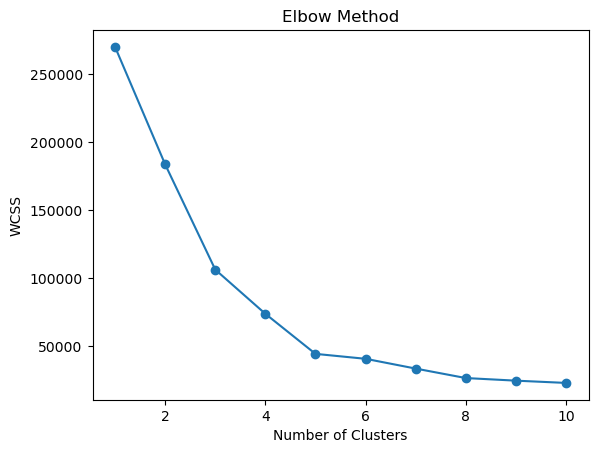

In [13]:
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()


In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X)

data['Cluster'] = clusters

C:\Users\jathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


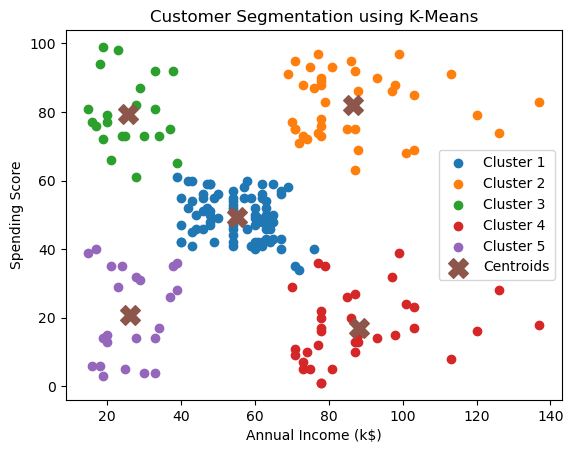

In [15]:
plt.scatter(X.iloc[clusters == 0,0], X.iloc[clusters == 0,1], label='Cluster 1')
plt.scatter(X.iloc[clusters == 1,0], X.iloc[clusters == 1,1], label='Cluster 2')
plt.scatter(X.iloc[clusters == 2,0], X.iloc[clusters == 2,1], label='Cluster 3')
plt.scatter(X.iloc[clusters == 3,0], X.iloc[clusters == 3,1], label='Cluster 4')
plt.scatter(X.iloc[clusters == 4,0], X.iloc[clusters == 4,1], label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            marker='X',
            s=200,
            label='Centroids')

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.legend()

plt.show()

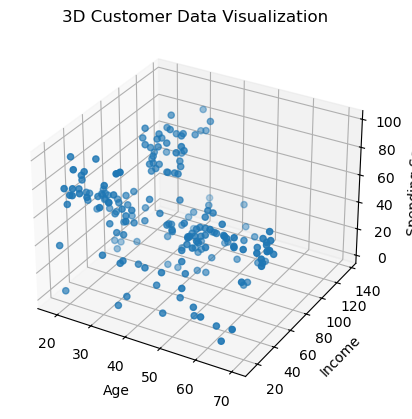

In [16]:
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.scatter(data['Age'],
           data['Annual Income (k$)'],
           data['Spending Score (1-100)'])

ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spending Score")

plt.title("3D Customer Data Visualization")

plt.show()

In [17]:
print(data['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


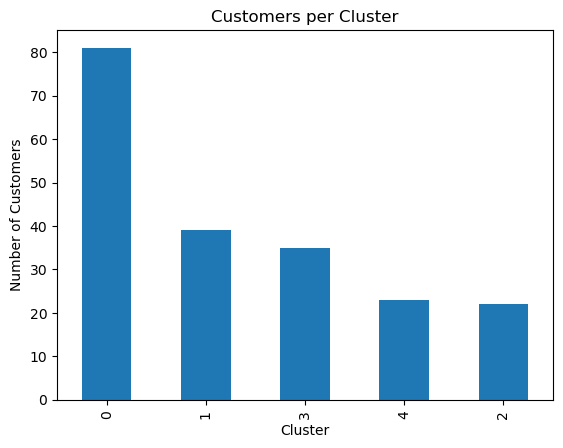

In [18]:
data['Cluster'].value_counts().plot(kind='bar')

plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
